In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
# Optional: make plots display inline in Jupyter
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

In [28]:
df = pd.read_csv('datasets/fuel/fuelcheck_pricehistory_2026_02.csv')
# ── Inspect ───────────────────────────────────────────────────────────────
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nFirst rows:')
df.head()

Shape: (66981, 8)

Column types:
ServiceStationName     object
Address                object
Suburb                 object
Postcode                int64
Brand                  object
FuelCode               object
PriceUpdatedDate       object
Price                 float64
dtype: object

Missing values:
ServiceStationName    0
Address               0
Suburb                0
Postcode              0
Brand                 0
FuelCode              0
PriceUpdatedDate      0
Price                 0
dtype: int64

First rows:


,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Medco Waratah,"36 LORNA ST, WARATAH NSW 2298",WARATAH,2298,Independent,E10,2026-02-01 00:05:31,148.5
1,Medco Waratah,"36 LORNA ST, WARATAH NSW 2298",WARATAH,2298,Independent,DL,2026-02-01 00:05:31,162.5
2,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,E10,2026-02-01 00:07:43,173.5
3,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,U91,2026-02-01 00:07:43,175.5
4,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,P98,2026-02-01 00:07:43,194.5


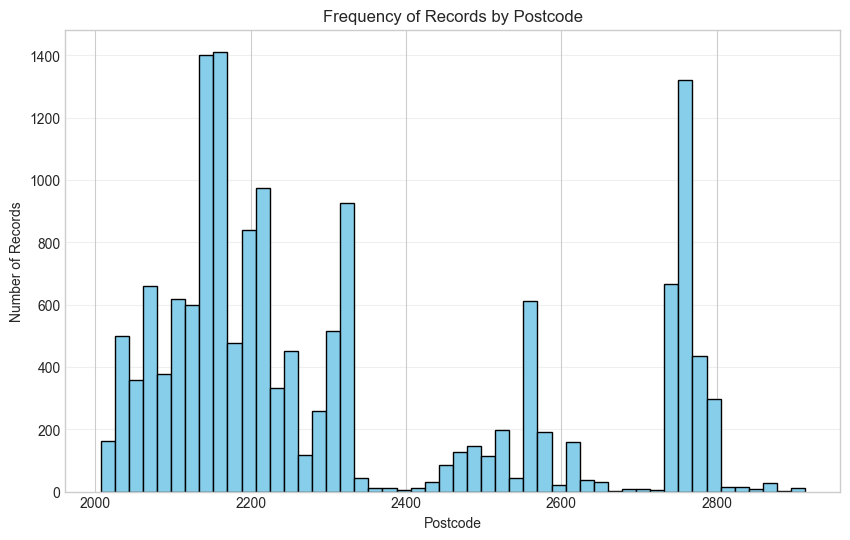

In [29]:
# Convert pandas objects to python strings for better interpretation
df['FuelCode'] = df['FuelCode'].astype(str)
df['Suburb'] = df['Suburb'].astype(str).str.lower()

# And filter so that is only E10 rows
df = df[df['FuelCode'] == "E10"].copy()

# And filter so that is only the relevant postcodes (<= 3000)
df = df[df['Postcode'] <= 3000]

# And show how many E10 data we have per postcode in this range
plt.figure(figsize=(10, 6))
plt.hist(df['Postcode'], bins=50, color='skyblue', edgecolor='black')
plt.title('Frequency of Records by Postcode')
plt.xlabel('Postcode')
plt.ylabel('Number of Records')
plt.grid(axis='y', alpha=0.3)

plt.show()

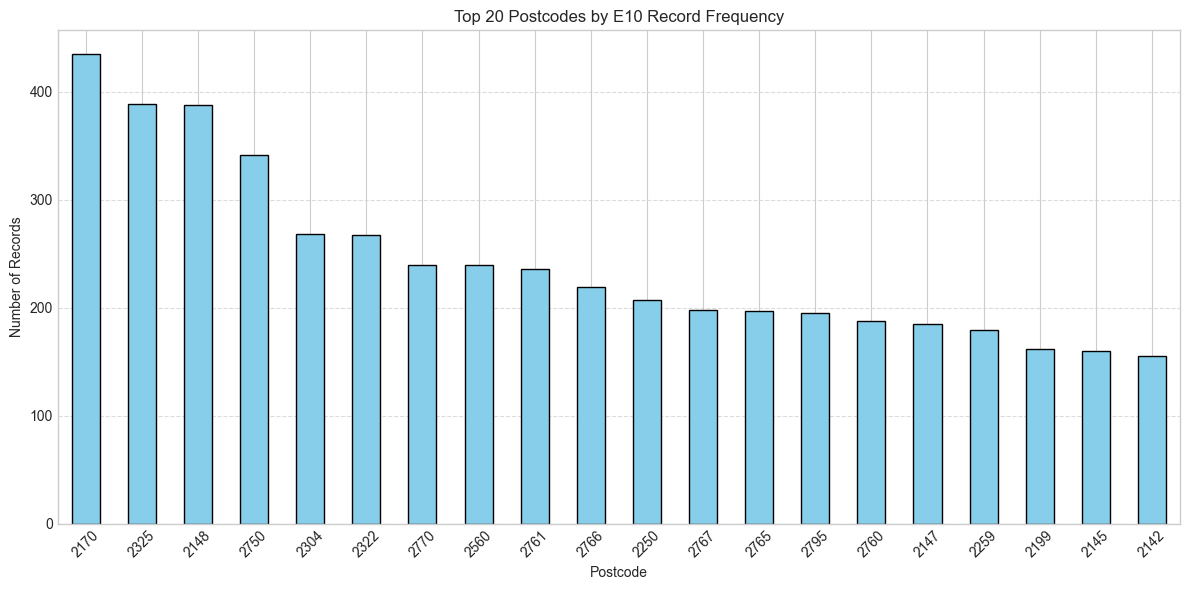

In [30]:
# That is useful, but it'll be even better to see directly which postcodes
# have the most data available.
top_postcodes = df['Postcode'].value_counts().head(20)

# Plot as a Bar Chart
plt.figure(figsize=(12, 6))
top_postcodes.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 20 Postcodes by E10 Record Frequency')
plt.xlabel('Postcode')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

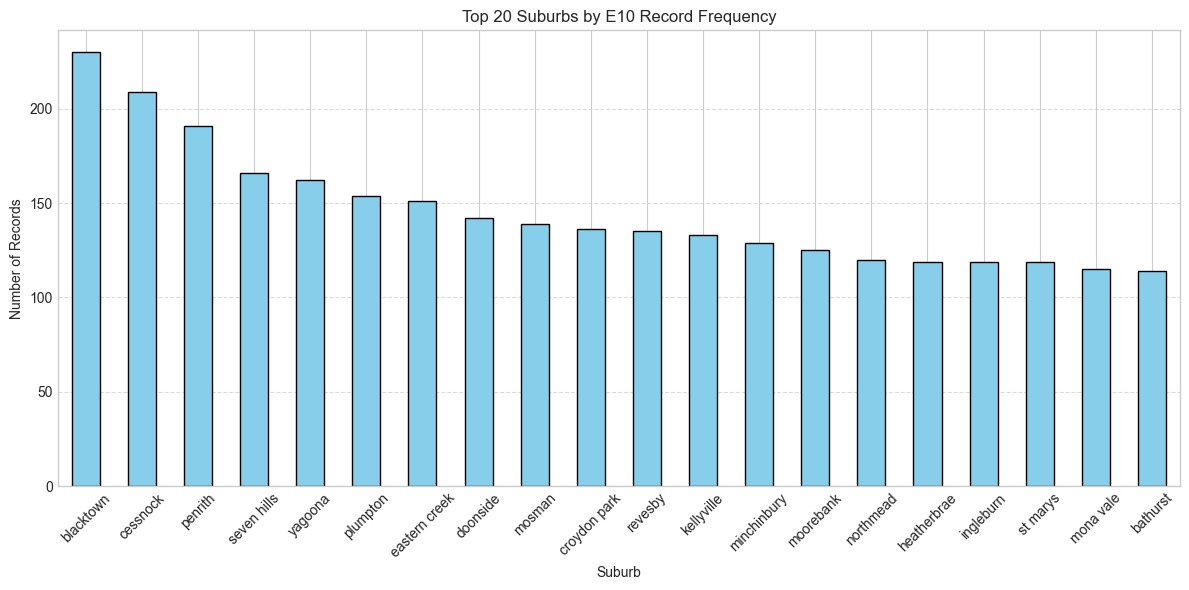

In [31]:
# Let's have the x-axis be Suburb instead; does it work?
top_suburbs = df['Suburb'].value_counts().head(20)

# Plot as a Bar Chart
plt.figure(figsize=(12, 6))
top_suburbs.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 20 Suburbs by E10 Record Frequency')
plt.xlabel('Suburb')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [32]:
# For now, let's only focus on only these top 20 postcodes
df = df[df['Postcode'].isin(top_postcodes.index)].copy()

# As expected, only 20 postcodes remaining
print(f"New shape: {df.shape}")
print(f"Unique postcodes remaining: {df['Postcode'].nunique()}")
print(df.head())

New shape: (4849, 8)
Unique postcodes remaining: 20
        ServiceStationName                                            Address  \
2       Speedway Sunnyholt               162 Sunnyholt Rd, Blacktown NSW 2148   
5     7-Eleven Minchinbury   1042 Great Western Highway, Minchinbury NSW 2770   
7     7-Eleven Minchinbury  Lot 3 Great Western Highway (Cnr John Hines Av...   
13        7-Eleven Colyton  104 Great Western Highway & Bennett Road, Coly...   
23  7-Eleven Eastern Creek  Lot 16 - 25 Great Western Highway, Eastern Cre...   

           Suburb  Postcode     Brand FuelCode     PriceUpdatedDate  Price  
2       blacktown      2148  Speedway      E10  2026-02-01 00:07:43  173.5  
5     minchinbury      2770  7-Eleven      E10  2026-02-01 00:33:12  186.9  
7     minchinbury      2770  7-Eleven      E10  2026-02-01 00:33:12  176.9  
13        colyton      2760  7-Eleven      E10  2026-02-01 00:36:10  174.9  
23  eastern creek      2766  7-Eleven      E10  2026-02-01 00:39:12  186.9  